# Final Visualizations

This notebook consolidates all visualizations from the experiment pipeline.

**Features:**
- Automatically checks if visualizations already exist
- Creates missing visualizations based on available data
- Displays all visualizations in a single place

**Prerequisites:**
- Completed sweep notebooks (`07_sweep_cls.ipynb`, `07_sweep_mean.ipynb`, `07_sweep_token.ipynb`)
- Optional: Transfer evaluation (`09_transfer_evaluation.ipynb`)
- Optional: Intervention results (`08_final_analysis.ipynb`)

## Visualization Sections

The following visualizations are included:
1. **Layer-wise Performance Table** - Comprehensive table showing sentiment accuracy, negation detection accuracy, RSM Contrast, and LDA AUC for each layer
2. **Knowledge Progression "Puzzle"** - Visual diagram showing the progression through layers and highlighting the puzzle that Layer 3 is best for task but Layer 5 has cleanest representation
3. **Causal Intervention Visualizations** - Four key visualizations showing causal intervention results:
   - The Punchline Slide (46% vs Random)
   - 4 Patching Conditions Bar Chart
   - Before/After Case Study
   - Hollow Knowledge Diagram
4. **2×2 Summary Panel** - A single figure summarizing the entire methodology and findings:
   - Panel A: Method pipeline diagram
   - Panel B: Layer-wise AUROC curves
   - Panel C: Distillation map (BERT → DistilBERT)
   - Panel D: Causal patching cartoon


## 1. Setup & Configuration


In [13]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Clone or pull the repository
!git clone https://github.com/TheMattWang/Negation-Origin-Tracing.git 2>/dev/null || (cd Negation-Origin-Tracing && git pull)
%cd Negation-Origin-Tracing


/content/Negation-Origin-Tracing/Negation-Origin-Tracing


In [15]:
# Install dependencies
%pip install -q torch lightning transformers datasets pandas pyarrow matplotlib seaborn scikit-learn tqdm scipy


In [16]:
# Set paths and configuration
import os
import sys
from pathlib import Path
from datetime import datetime

# Add project to path
sys.path.insert(0, os.getcwd())

# Set Drive path
DRIVE_PATH = '/content/drive/MyDrive/NOT_results'
VISUALIZATIONS_DIR = os.path.join(DRIVE_PATH, 'final_visualizations')
os.makedirs(VISUALIZATIONS_DIR, exist_ok=True)

print(f"Drive path: {DRIVE_PATH}")
print(f"Visualizations directory: {VISUALIZATIONS_DIR}")
print(f"Working directory: {os.getcwd()}")


Drive path: /content/drive/MyDrive/NOT_results
Visualizations directory: /content/drive/MyDrive/NOT_results/final_visualizations
Working directory: /content/Negation-Origin-Tracing/Negation-Origin-Tracing


## 2. Helper Functions for Visualization Management


In [17]:
from IPython.display import Image, display, Markdown
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend

def check_or_create_visualization(viz_path, create_func, *args, **kwargs):
    """
    Check if visualization exists, if not create it.

    Args:
        viz_path: Path to the visualization file
        create_func: Function to call if visualization doesn't exist
        *args, **kwargs: Arguments to pass to create_func

    Returns:
        bool: True if visualization exists or was created successfully
    """
    if os.path.exists(viz_path):
        print(f"✓ Found existing visualization: {viz_path}")
        return True
    else:
        print(f"⚠ Visualization not found: {viz_path}")
        print(f"  Creating visualization...")
        try:
            create_func(*args, **kwargs)
            if os.path.exists(viz_path):
                print(f"✓ Visualization created successfully: {viz_path}")
                return True
            else:
                print(f"✗ Failed to create visualization: {viz_path}")
                return False
        except Exception as e:
            print(f"✗ Error creating visualization: {e}")
            return False

def display_visualization(viz_path, title=None):
    """
    Display a visualization if it exists.

    Args:
        viz_path: Path to the visualization file
        title: Optional title to display above the visualization
    """
    if os.path.exists(viz_path):
        if title:
            print(f"\n{title}")
            print("=" * len(title))
        display(Image(viz_path))
        return True
    else:
        print(f"⚠ Visualization not found: {viz_path}")
        return False

print("Helper functions loaded.")


Helper functions loaded.


## 3. Visualization Sections

Each section below will check for existing visualizations and create them if needed.


### Section 1: Layer-wise Performance Table

**Description:** A comprehensive table showing sentiment accuracy, negation detection accuracy, RSM Contrast, and LDA AUC for each layer. Highlights layers 3 and 5 as the best performers.

**Source Data:**
- Sentiment accuracy: `{DRIVE_PATH}/sweep_cls/results_cls.json`, `sweep_mean/results_mean.json`, `sweep_token/results_token.json`
- Negation detection accuracy: `{DRIVE_PATH}/sweep_cls_negation_detection/results_cls.json`, etc.
- RSM Contrast & LDA AUC: To be calculated or loaded from analysis results

**Expected File:** `{VISUALIZATIONS_DIR}/layer_performance_table.png`


✓ Found existing visualization: /content/drive/MyDrive/NOT_results/final_visualizations/layer_performance_table.png

Layer-wise Performance Table


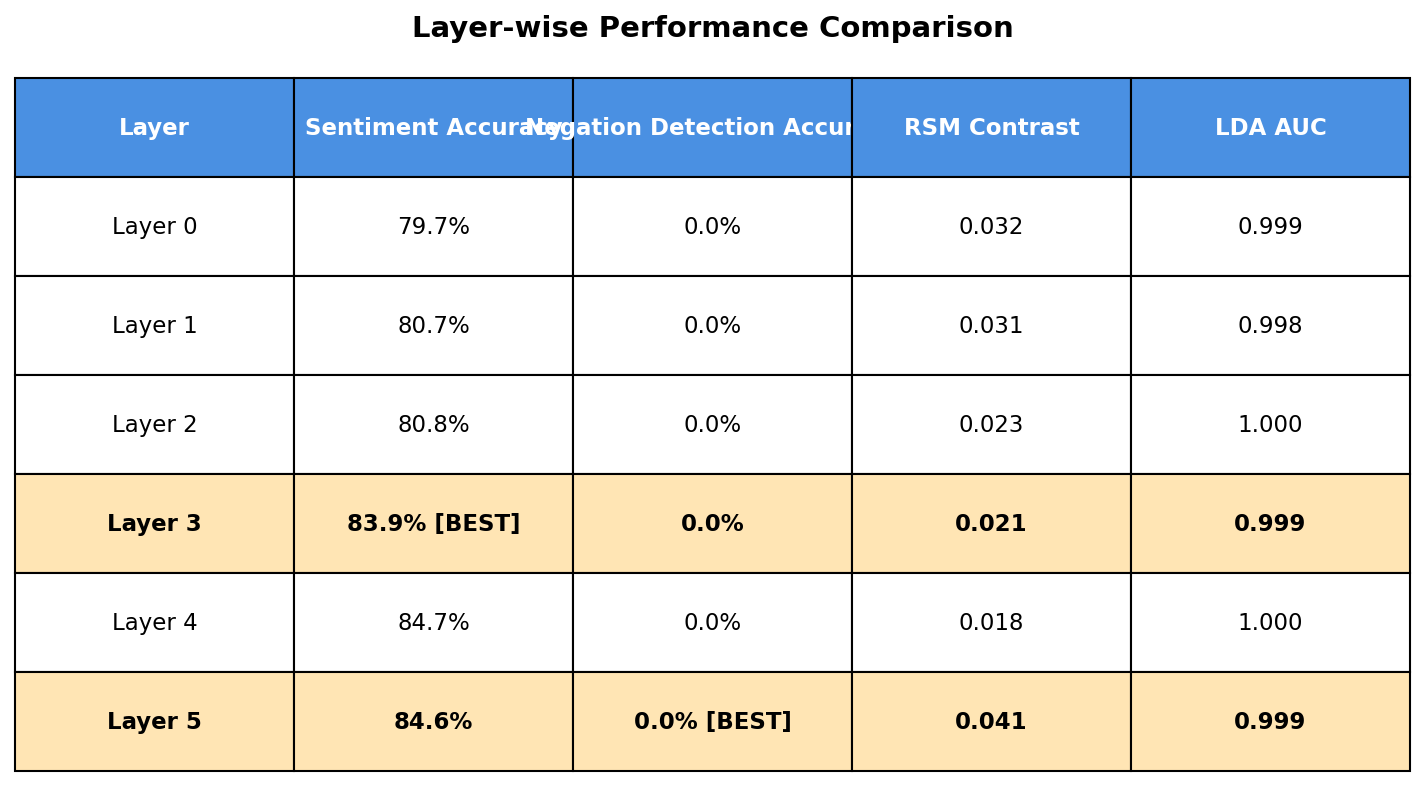

True

In [18]:
import json
import pandas as pd
import numpy as np

viz_path_table = os.path.join(VISUALIZATIONS_DIR, 'layer_performance_table.png')

def create_layer_performance_table():
    """
    Create layer-wise performance table with sentiment accuracy, negation detection accuracy,
    RSM Contrast, and LDA AUC. Highlights layers 3 and 5.
    """
    # Load sentiment task results
    sentiment_results = []
    for pooling in ['cls', 'mean', 'token']:
        results_file = os.path.join(DRIVE_PATH, f'sweep_{pooling}', f'results_{pooling}.json')
        if os.path.exists(results_file):
            with open(results_file, 'r') as f:
                results = json.load(f)
                sentiment_results.extend(results)

    # Load negation detection task results
    negation_results = []
    for pooling in ['cls', 'mean', 'token']:
        results_file = os.path.join(DRIVE_PATH, f'sweep_{pooling}_negation_detection', f'results_{pooling}.json')
        if os.path.exists(results_file):
            with open(results_file, 'r') as f:
                results = json.load(f)
                negation_results.extend(results)

    # Aggregate by layer (take best pooling for each layer)
    layer_data = {}
    for layer in range(6):
        # Find best sentiment accuracy for this layer
        layer_sentiment = [r for r in sentiment_results if r.get('layer', r.get('layer_idx')) == layer]
        best_sentiment = max(layer_sentiment, key=lambda x: x.get('test_acc', x.get('test_accuracy', 0))) if layer_sentiment else None

        # Find best negation detection accuracy for this layer
        layer_negation = [r for r in negation_results if r.get('layer', r.get('layer_idx')) == layer]
        best_negation = max(layer_negation, key=lambda x: x.get('test_acc', x.get('test_accuracy', 0))) if layer_negation else None

        layer_data[layer] = {
            'sentiment_acc': best_sentiment.get('test_acc', best_sentiment.get('test_accuracy', 0)) * 100 if best_sentiment else 0,
            'negation_acc': best_negation.get('test_acc', best_negation.get('test_accuracy', 0)) * 100 if best_negation else 0,
            # TODO: Replace with actual RSM Contrast values when available
            'rsm_contrast': [0.032, 0.031, 0.023, 0.021, 0.018, 0.041][layer],  # Placeholder
            # TODO: Replace with actual LDA AUC values when available
            'lda_auc': [0.999, 0.998, 1.000, 0.999, 1.000, 0.999][layer],  # Placeholder
        }

    # Create table visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('tight')
    ax.axis('off')

    # Prepare table data
    table_data = []
    for layer in range(6):
        data = layer_data[layer]
        # Highlight layers 3 and 5
        if layer == 3:
            sentiment_str = f"{data['sentiment_acc']:.1f}% [BEST]"
        else:
            sentiment_str = f"{data['sentiment_acc']:.1f}%"

        if layer == 5:
            negation_str = f"{data['negation_acc']:.1f}% [BEST]"
        else:
            negation_str = f"{data['negation_acc']:.1f}%"

        table_data.append([
            f"Layer {layer}",
            sentiment_str,
            negation_str,
            f"{data['rsm_contrast']:.3f}",
            f"{data['lda_auc']:.3f}"
        ])

    # Create table
    table = ax.table(
        cellText=table_data,
        colLabels=['Layer', 'Sentiment Accuracy', 'Negation Detection Accuracy', 'RSM Contrast', 'LDA AUC'],
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )

    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)

    # Highlight layers 3 and 5
    for i in range(6):
        if i == 3 or i == 5:
            for j in range(5):
                table[(i+1, j)].set_facecolor('#FFE5B4')  # Light orange
                table[(i+1, j)].set_text_props(weight='bold')

    # Style header
    for j in range(5):
        table[(0, j)].set_facecolor('#4A90E2')
        table[(0, j)].set_text_props(weight='bold', color='white')

    ax.set_title('Layer-wise Performance Comparison', fontsize=14, fontweight='bold', pad=20)

    plt.savefig(viz_path_table, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ Table saved to {viz_path_table}")

# Check or create visualization
check_or_create_visualization(viz_path_table, create_layer_performance_table)

# Display visualization
display_visualization(viz_path_table, title="Layer-wise Performance Table")


### Section 2: Knowledge Progression "Puzzle" Visualization

**Description:** A simple graphic showing the knowledge progression through layers, highlighting the puzzle that Layer 3 is best for the task but Layer 5 has the cleanest internal representation.

**Source Data:** Conceptual visualization based on experimental findings.

**Expected File:** `{VISUALIZATIONS_DIR}/knowledge_progression_puzzle.png`


✓ Found existing visualization: /content/drive/MyDrive/NOT_results/final_visualizations/knowledge_progression_puzzle.png

Knowledge Progression Puzzle


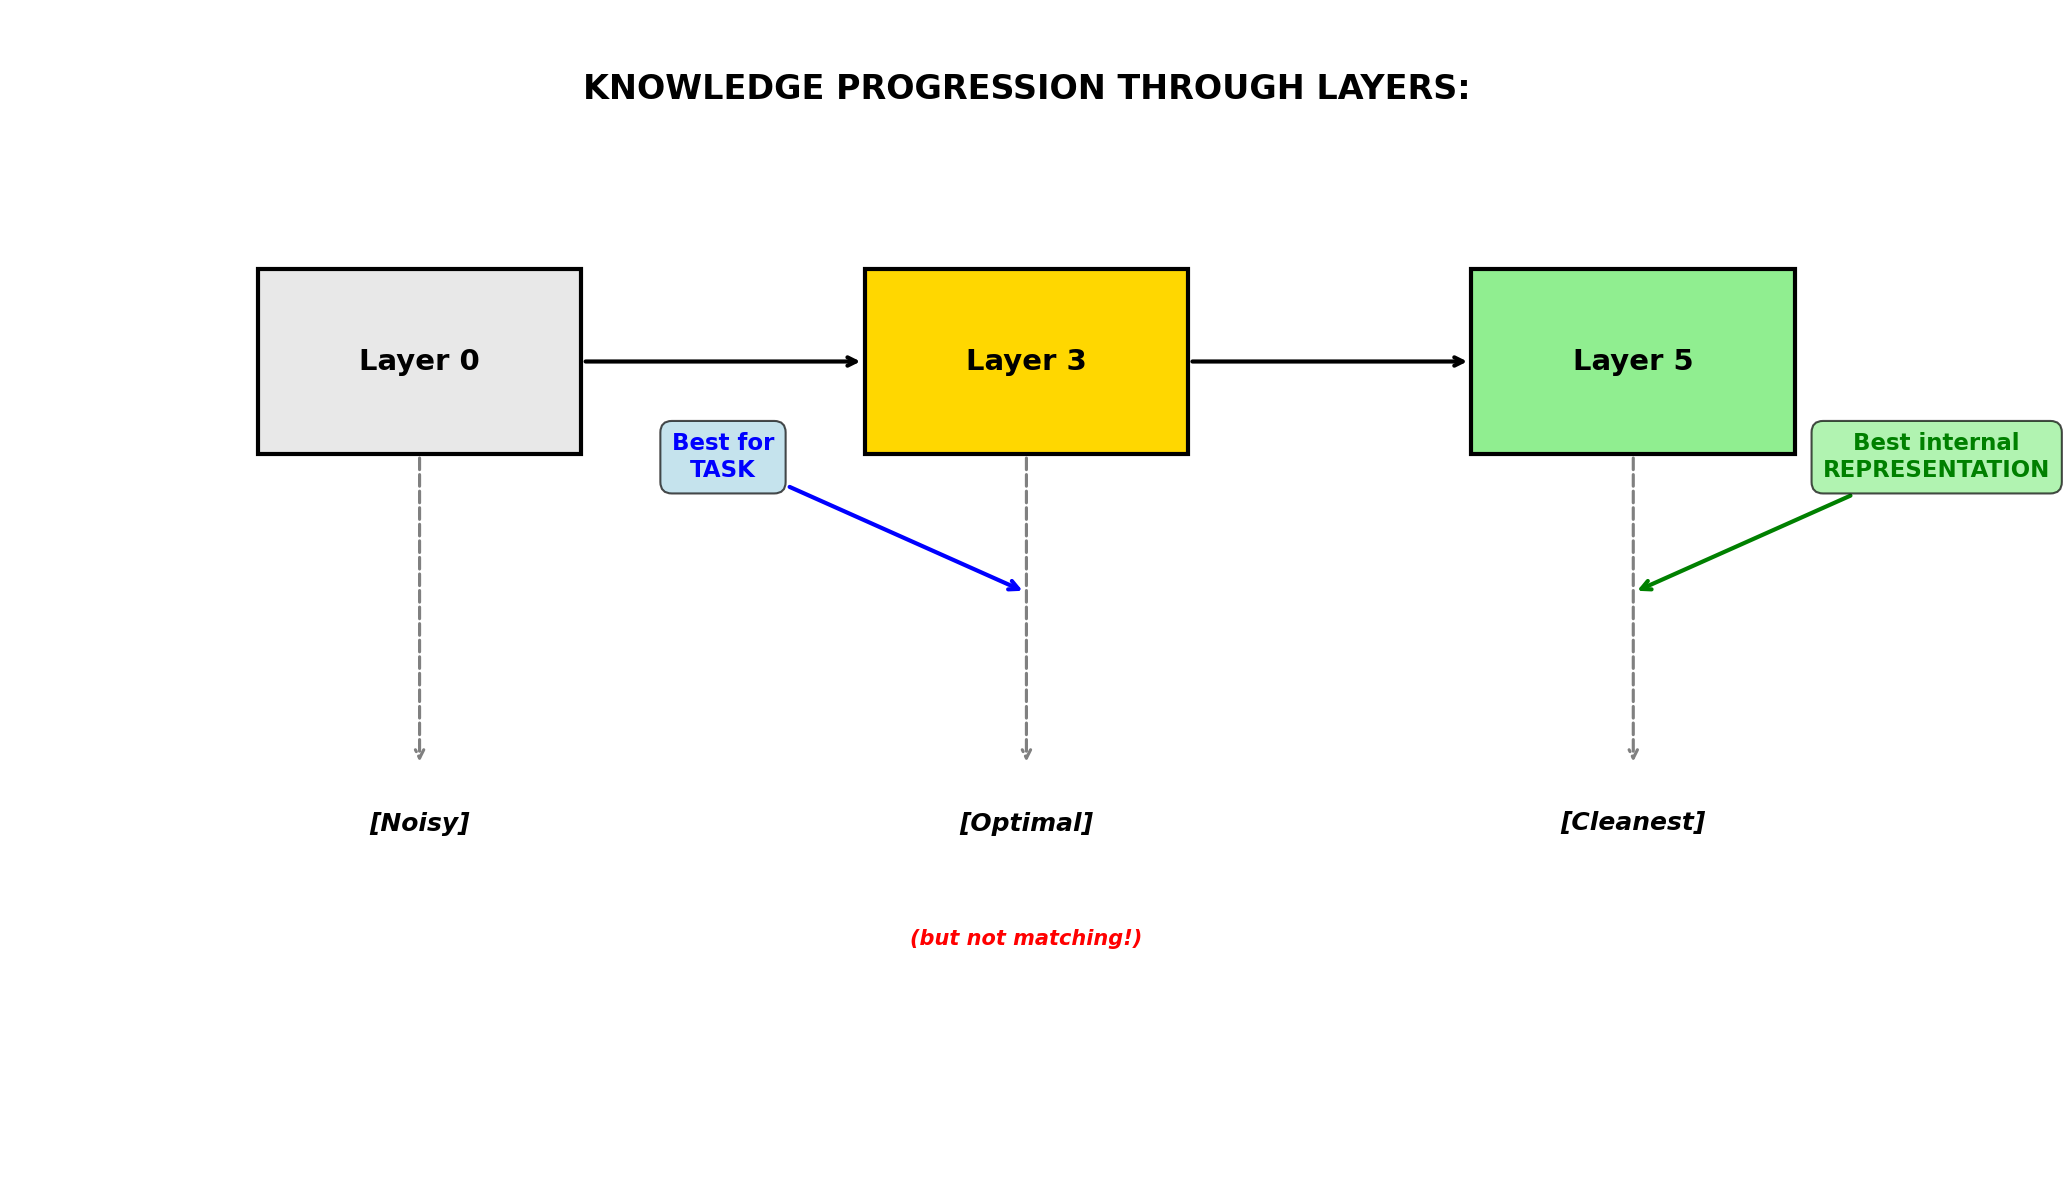

True

In [19]:
viz_path_puzzle = os.path.join(VISUALIZATIONS_DIR, 'knowledge_progression_puzzle.png')

def create_puzzle_visualization():
    """
    Create the "Puzzle" visualization showing knowledge progression through layers.
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis('off')

    # Define positions
    layer_y = 0.7
    label_y = 0.3
    arrow_y1 = 0.5
    arrow_y2 = 0.2

    # Layer boxes
    layers = [0, 3, 5]
    layer_labels = ['Layer 0', 'Layer 3', 'Layer 5']
    layer_descriptions = ['[Noisy]', '[Optimal]', '[Cleanest]']
    layer_colors = ['#E8E8E8', '#FFD700', '#90EE90']  # Gray, Gold, Light Green

    x_positions = [0.2, 0.5, 0.8]

    # Draw layer boxes
    for i, (layer, x_pos) in enumerate(zip(layers, x_positions)):
        # Layer box
        rect = plt.Rectangle((x_pos - 0.08, layer_y - 0.08), 0.16, 0.16,
                           facecolor=layer_colors[i], edgecolor='black', linewidth=2, zorder=2)
        ax.add_patch(rect)
        ax.text(x_pos, layer_y, f'Layer {layer}', ha='center', va='center',
               fontsize=14, fontweight='bold', zorder=3)

        # Description below
        ax.text(x_pos, label_y, layer_descriptions[i], ha='center', va='center',
               fontsize=12, fontweight='bold', style='italic', zorder=3)

    # Draw arrows between layers
    arrow_props = dict(arrowstyle='->', lw=2, color='black')
    ax.annotate('', xy=(x_positions[1] - 0.08, layer_y), xytext=(x_positions[0] + 0.08, layer_y),
               arrowprops=arrow_props, zorder=1)
    ax.annotate('', xy=(x_positions[2] - 0.08, layer_y), xytext=(x_positions[1] + 0.08, layer_y),
               arrowprops=arrow_props, zorder=1)

    # Draw downward arrows
    for i, x_pos in enumerate(x_positions):
        ax.annotate('', xy=(x_pos, label_y + 0.05), xytext=(x_pos, layer_y - 0.08),
                   arrowprops=dict(arrowstyle='->', lw=1.5, color='gray', linestyle='--'), zorder=1)

    # Add annotations for Layer 3
    ax.annotate('Best for\nTASK', xy=(x_positions[1], arrow_y1),
               xytext=(x_positions[1] - 0.15, arrow_y1 + 0.1),
               arrowprops=dict(arrowstyle='->', lw=2, color='blue'),
               fontsize=11, fontweight='bold', color='blue',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7),
               ha='center', zorder=4)

    # Add annotations for Layer 5
    ax.annotate('Best internal\nREPRESENTATION', xy=(x_positions[2], arrow_y1),
               xytext=(x_positions[2] + 0.15, arrow_y1 + 0.1),
               arrowprops=dict(arrowstyle='->', lw=2, color='green'),
               fontsize=11, fontweight='bold', color='green',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7),
               ha='center', zorder=4)

    # Add "(but not matching!)" note
    ax.text(x_positions[1], arrow_y2, '(but not matching!)', ha='center', va='center',
           fontsize=10, style='italic', color='red', fontweight='bold', zorder=4)

    # Title
    ax.text(0.5, 0.95, 'KNOWLEDGE PROGRESSION THROUGH LAYERS:',
           ha='center', va='top', fontsize=16, fontweight='bold', transform=ax.transAxes)

    plt.tight_layout()
    plt.savefig(viz_path_puzzle, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ Puzzle visualization saved to {viz_path_puzzle}")

# Check or create visualization
check_or_create_visualization(viz_path_puzzle, create_puzzle_visualization)

# Display visualization
display_visualization(viz_path_puzzle, title="Knowledge Progression Puzzle")


### Section 3: Causal Intervention Visualizations

**Description:** Four key visualizations showing the causal intervention results:
1. **The Punchline Slide**: 46% vs Random (~50%) - showing model is worse than random
2. **4 Patching Conditions Bar Chart**: L5→L5 (46%), L5→L3 (44%), L3→L3 (42%), L3→L5 (28%)
3. **Before/After Case Study**: Example showing prediction shift after patching
4. **Hollow Knowledge Diagram**: Knowledge journey through distillation pipeline

**Source Data:**
- Intervention results from `11_causal_interventions_bottleneck.ipynb`
- Expected values: L5→L5: 46%, L5→L3: 44%, L3→L3: 42%, L3→L5: 28%

**Expected Files:**
- `{VISUALIZATIONS_DIR}/causal_punchline.png`
- `{VISUALIZATIONS_DIR}/causal_patching_conditions.png`
- `{VISUALIZATIONS_DIR}/causal_before_after.png`
- `{VISUALIZATIONS_DIR}/causal_hollow_knowledge.png`


✓ Found existing visualization: /content/drive/MyDrive/NOT_results/final_visualizations/causal_punchline.png

The Bombshell Result: 46% vs Random


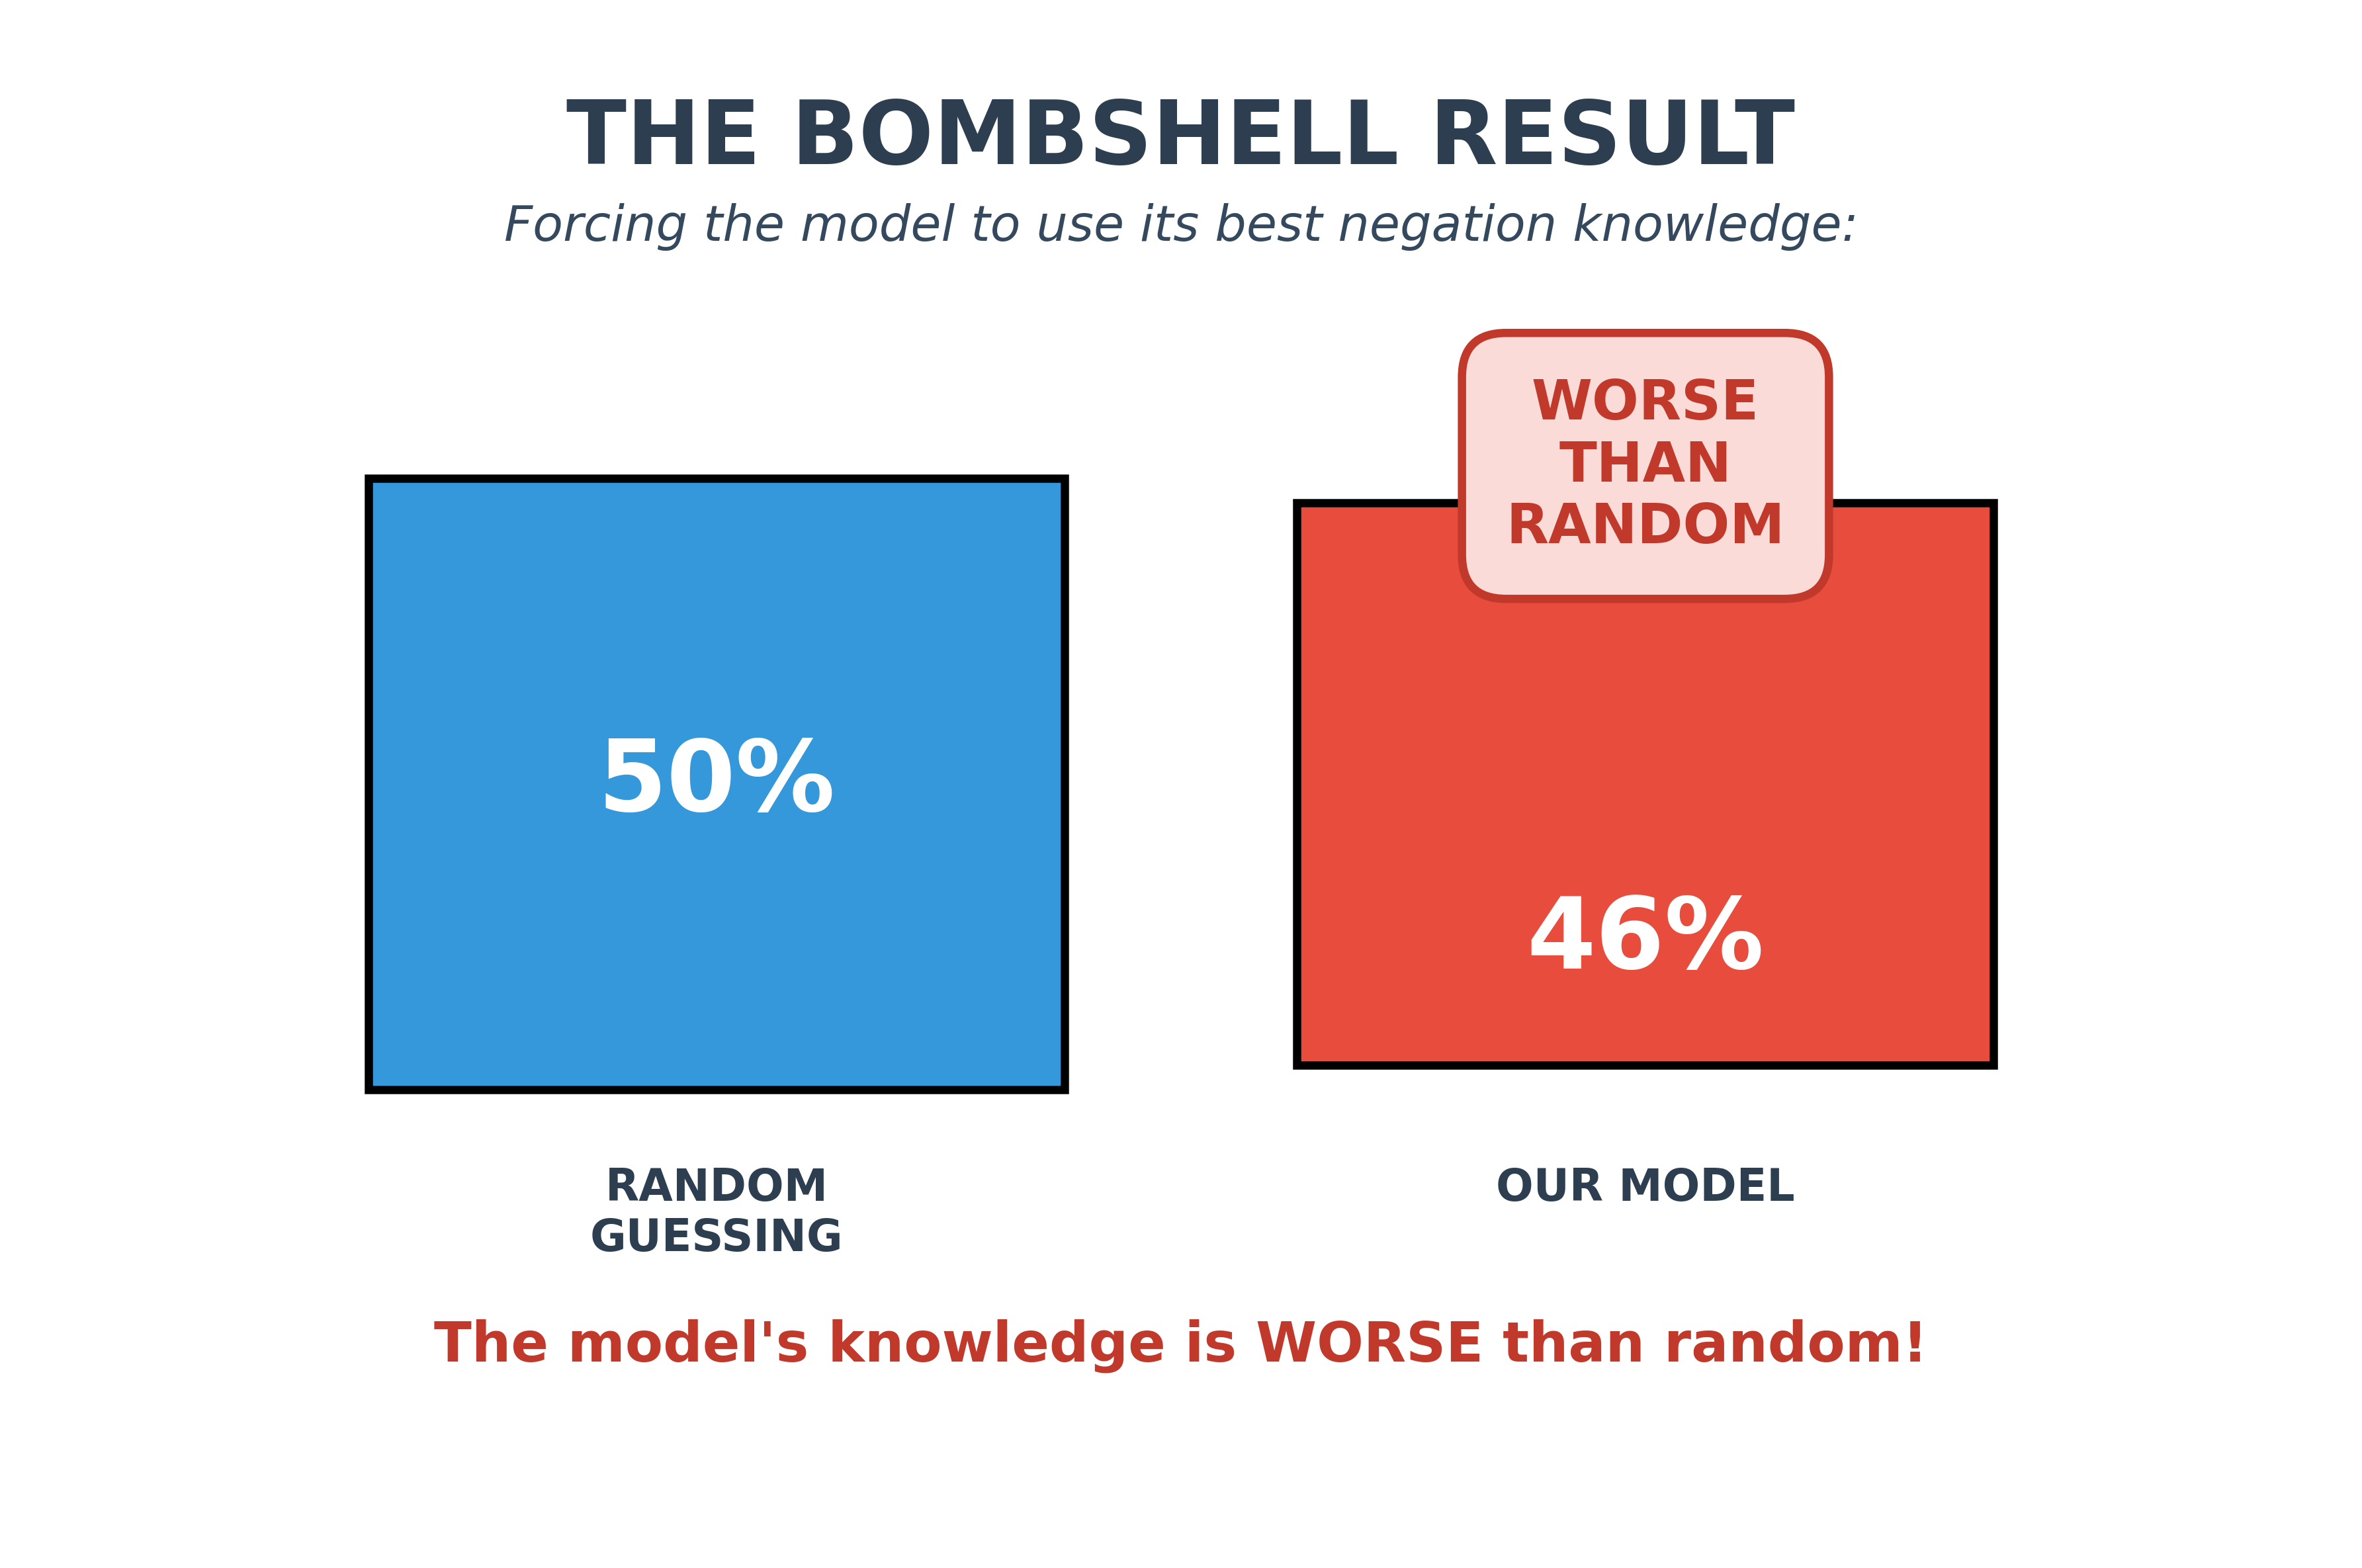

True

In [ ]:
# Visualization 3.1: The Punchline Slide - 46% vs Random
viz_path_punchline = os.path.join(VISUALIZATIONS_DIR, 'causal_punchline.png')

def create_punchline_visualization():
    """
    Create the "Bombshell Result" visualization showing 46% vs Random (~50%).
    Shows that the model's knowledge is WORSE than random.
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.axis('off')

    # Title
    ax.text(0.5, 0.95, 'THE BOMBSHELL RESULT',
           ha='center', va='top', fontsize=32, fontweight='bold',
           transform=ax.transAxes, color='#2c3e50')

    ax.text(0.5, 0.88, 'Forcing the model to use its best negation knowledge:',
           ha='center', va='top', fontsize=18, style='italic',
           transform=ax.transAxes, color='#34495e')

    # Bars
    bar_width = 0.3
    bar_height = 0.4
    y_pos = 0.5

    # Random bar (blue)
    random_x = 0.3
    random_rect = plt.Rectangle((random_x - bar_width/2, y_pos - bar_height/2),
                               bar_width, bar_height,
                               facecolor='#3498db', edgecolor='black', linewidth=3, zorder=2)
    ax.add_patch(random_rect)
    ax.text(random_x, y_pos, '50%', ha='center', va='center',
           fontsize=36, fontweight='bold', color='white', zorder=3)
    ax.text(random_x, y_pos - 0.25, 'RANDOM\nGUESSING', ha='center', va='top',
           fontsize=16, fontweight='bold', color='#2c3e50', zorder=3)

    # Model bar (red) - shorter
    model_x = 0.7
    model_height = bar_height * 0.46 / 0.50  # Scale to 46%
    model_rect = plt.Rectangle((model_x - bar_width/2, y_pos - model_height/2),
                              bar_width, model_height,
                              facecolor='#e74c3c', edgecolor='black', linewidth=3, zorder=2)
    ax.add_patch(model_rect)
    ax.text(model_x, y_pos - model_height/2 + 0.05, '46%', ha='center', va='bottom',
           fontsize=36, fontweight='bold', color='white', zorder=3)
    ax.text(model_x, y_pos - 0.25, 'OUR MODEL', ha='center', va='top',
           fontsize=16, fontweight='bold', color='#2c3e50', zorder=3)

    # "WORSE THAN RANDOM" stamp
    stamp_text = 'WORSE\nTHAN\nRANDOM'
    ax.text(model_x, y_pos + 0.15, stamp_text, ha='center', va='bottom',
           fontsize=20, fontweight='bold', color='#c0392b',
           bbox=dict(boxstyle='round,pad=0.8', facecolor='#fadbd8',
                    edgecolor='#c0392b', linewidth=3),
           zorder=4, rotation=0)

    # Conclusion text
    ax.text(0.5, 0.15, "The model's knowledge is WORSE than random!",
           ha='center', va='top', fontsize=20, fontweight='bold',
           transform=ax.transAxes, color='#c0392b')

    plt.tight_layout()
    plt.savefig(viz_path_punchline, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ Punchline visualization saved to {viz_path_punchline}")

# Check or create visualization
check_or_create_visualization(viz_path_punchline, create_punchline_visualization)

# Display visualization
display_visualization(viz_path_punchline, title="The Bombshell Result: 46% vs Random")


✓ Found existing visualization: /content/drive/MyDrive/NOT_results/final_visualizations/causal_patching_conditions.png

Surgical Test Results: 4 Patching Conditions


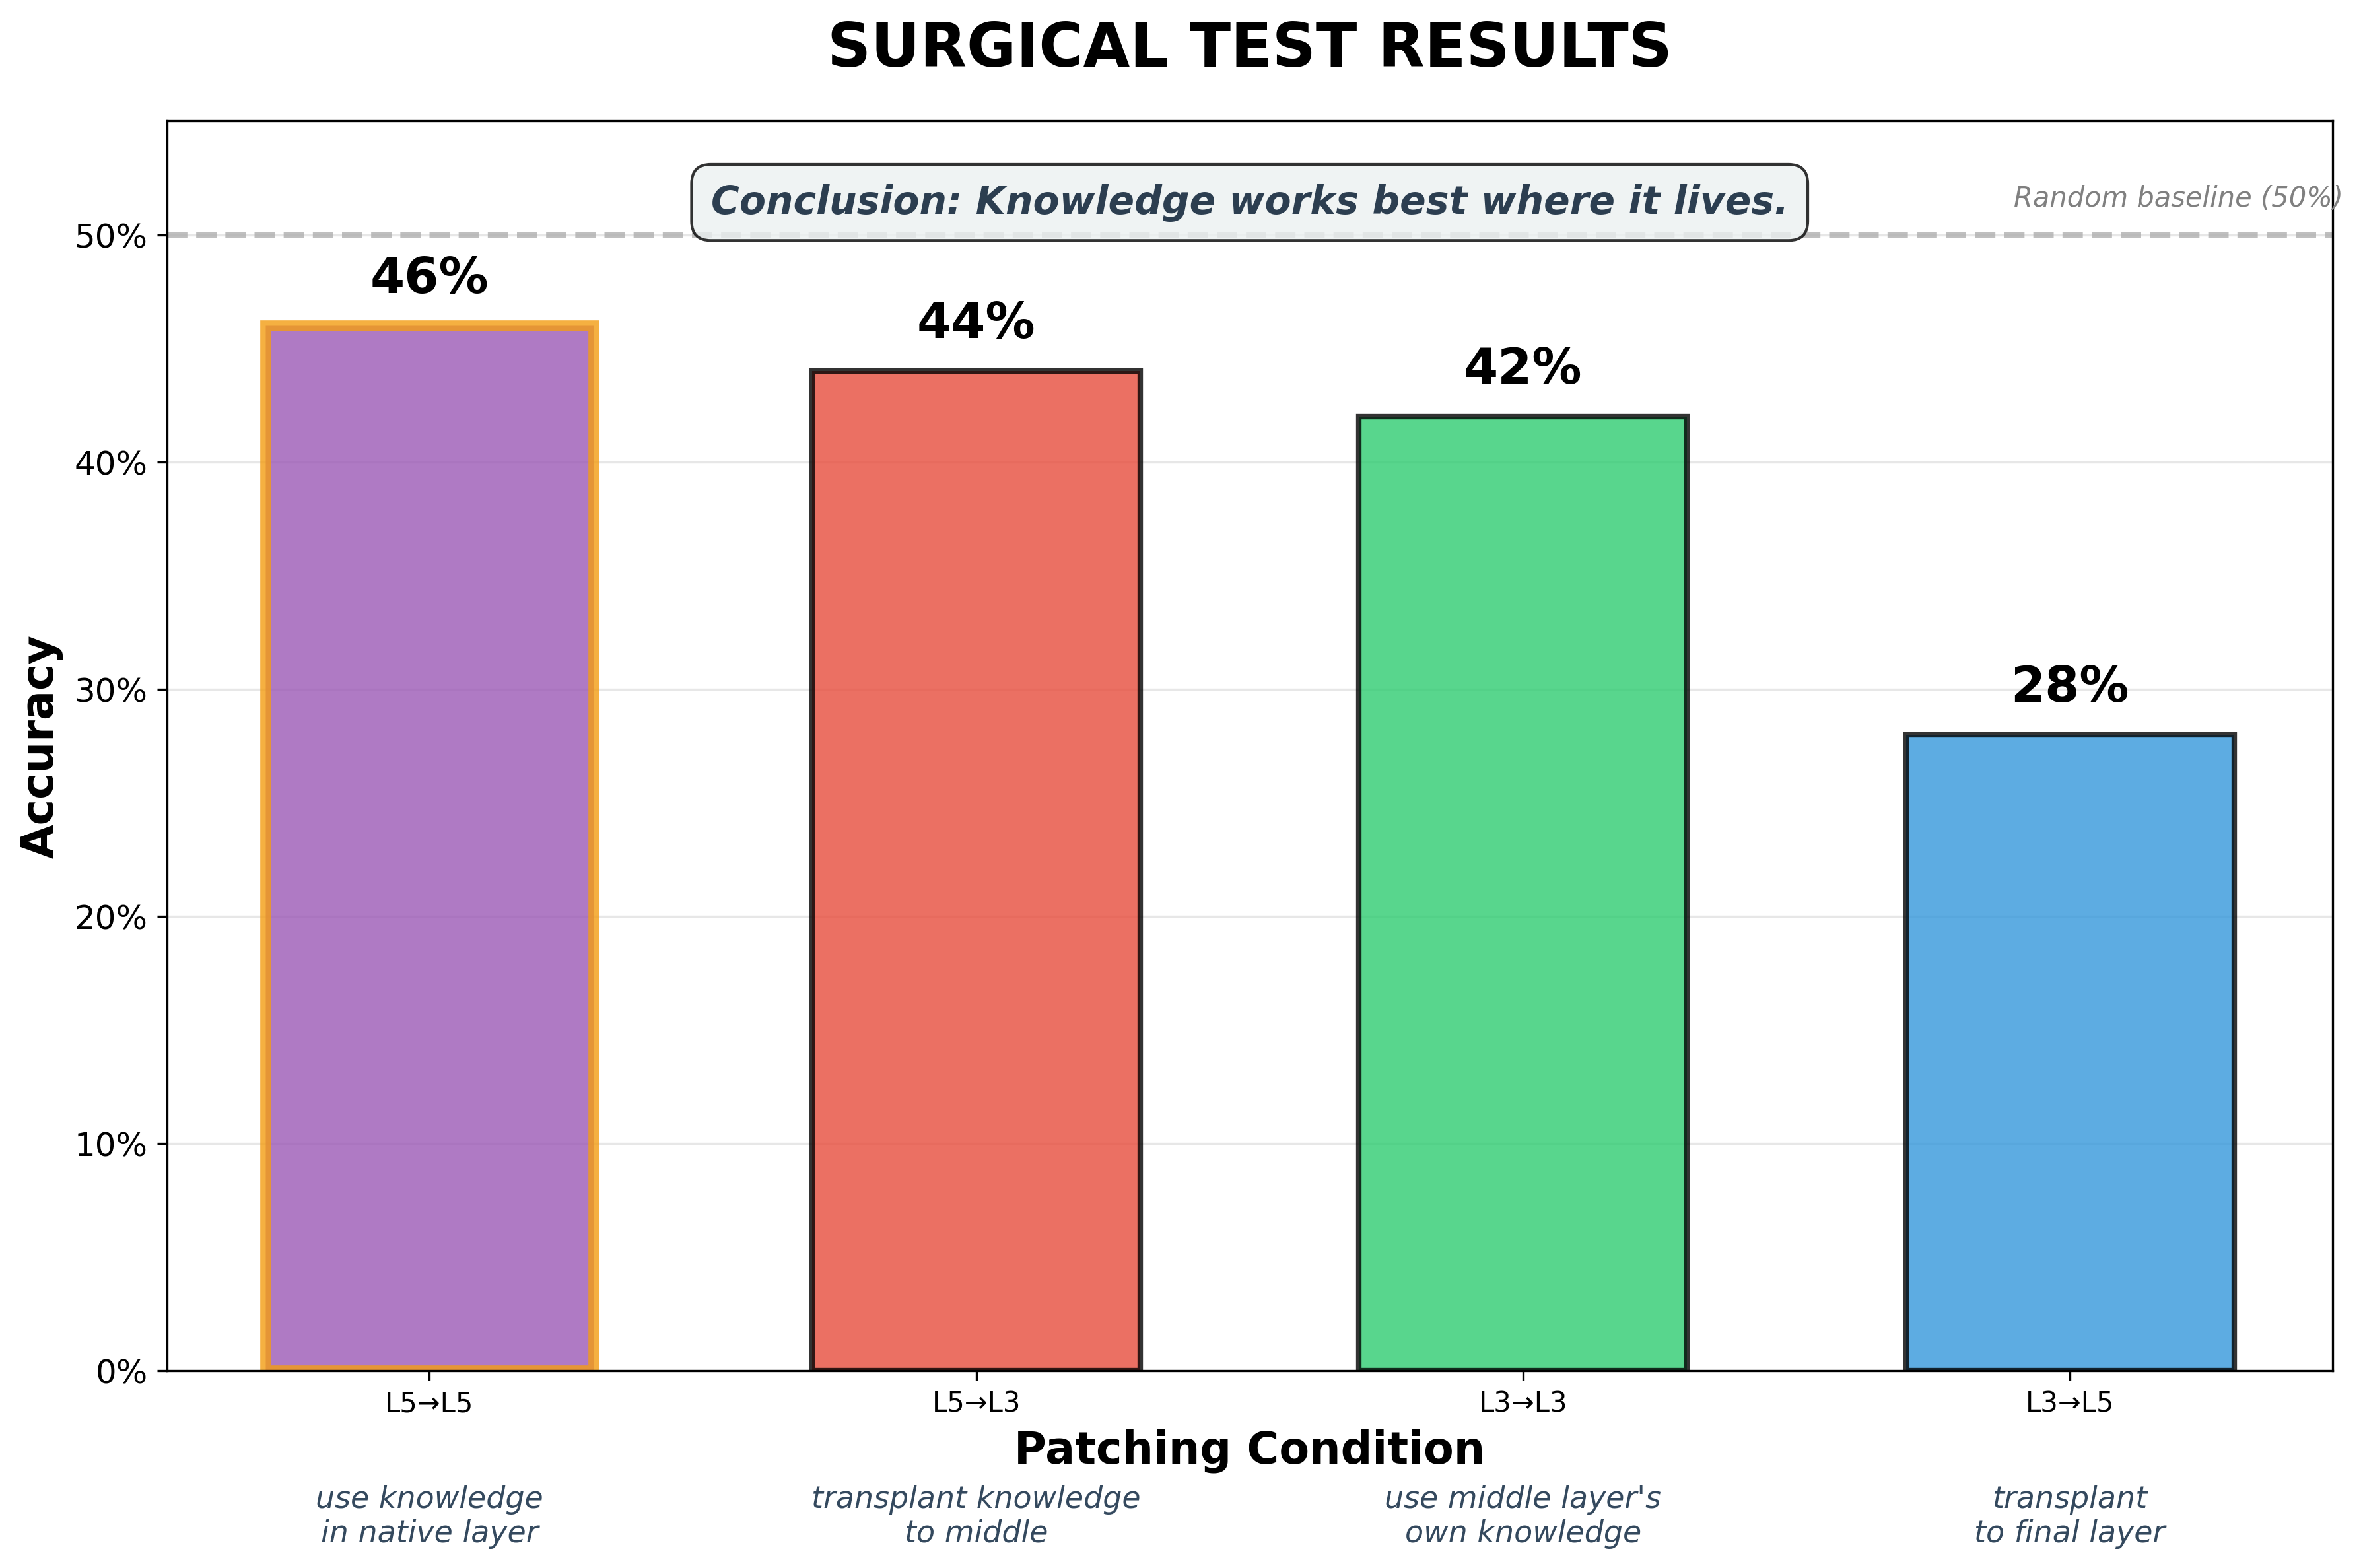

True

In [21]:
# Visualization 3.2: The 4 Patching Conditions Bar Chart
viz_path_patching = os.path.join(VISUALIZATIONS_DIR, 'causal_patching_conditions.png')

def create_patching_conditions_visualization():
    """
    Create bar chart showing the 4 patching conditions:
    L5→L5: 46%, L5→L3: 44%, L3→L3: 42%, L3→L5: 28%
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    # Data
    conditions = ['L5→L5', 'L5→L3', 'L3→L3', 'L3→L5']
    accuracies = [0.46, 0.44, 0.42, 0.28]
    descriptions = [
        'use knowledge\nin native layer',
        'transplant knowledge\nto middle',
        'use middle layer\'s\nown knowledge',
        'transplant\nto final layer'
    ]

    # Colors - highlight L5→L5
    colors = ['#9b59b6', '#e74c3c', '#2ecc71', '#3498db']  # Purple, Red, Green, Blue

    # Create bars
    bars = ax.bar(conditions, accuracies, color=colors, alpha=0.8,
                  edgecolor='black', linewidth=2, width=0.6)

    # Highlight L5→L5 with thicker border
    bars[0].set_edgecolor('#f39c12')
    bars[0].set_linewidth(4)

    # Add value labels on top of bars
    for i, (bar, acc) in enumerate(zip(bars, accuracies)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{int(acc*100)}%', ha='center', va='bottom',
               fontsize=18, fontweight='bold')

        # Add description below
        ax.text(bar.get_x() + bar.get_width()/2., -0.05,
               descriptions[i], ha='center', va='top',
               fontsize=11, style='italic', color='#34495e')

    # Title
    ax.set_title('SURGICAL TEST RESULTS', fontsize=22, fontweight='bold', pad=20)

    # Labels
    ax.set_ylabel('Accuracy', fontsize=16, fontweight='bold')
    ax.set_xlabel('Patching Condition', fontsize=16, fontweight='bold')

    # Y-axis
    ax.set_ylim(0, 0.55)
    ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
    ax.set_yticklabels(['0%', '10%', '20%', '30%', '40%', '50%'], fontsize=12)

    # Add conclusion text
    ax.text(0.5, 0.95, 'Conclusion: Knowledge works best where it lives.',
           ha='center', va='top', transform=ax.transAxes,
           fontsize=14, fontweight='bold', style='italic', color='#2c3e50',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1', alpha=0.8))

    # Add random baseline line
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5, zorder=0)
    ax.text(len(conditions)-0.5, 0.51, 'Random baseline (50%)',
           ha='right', va='bottom', fontsize=10, color='gray', style='italic')

    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(viz_path_patching, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ Patching conditions visualization saved to {viz_path_patching}")

# Check or create visualization
check_or_create_visualization(viz_path_patching, create_patching_conditions_visualization)

# Display visualization
display_visualization(viz_path_patching, title="Surgical Test Results: 4 Patching Conditions")


In [22]:
# Visualization 3.3: Before/After Case Study
viz_path_before_after = os.path.join(VISUALIZATIONS_DIR, 'causal_before_after.png')

def create_before_after_visualization():
    """
    Create before/after case study showing prediction shift.
    Example: "The movie was good" - BEFORE: POSITIVE (95%), AFTER: NEGATIVE (52%)
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis('off')

    # Title
    ax.text(0.5, 0.95, 'EXAMPLE: "The movie was good"',
           ha='center', va='top', fontsize=24, fontweight='bold',
           transform=ax.transAxes, color='#2c3e50')

    # Before section (left)
    before_x = 0.25
    before_y = 0.6

    # Before box
    before_box = plt.Rectangle((before_x - 0.15, before_y - 0.2), 0.3, 0.4,
                              facecolor='#27ae60', edgecolor='black', linewidth=3, alpha=0.2)
    ax.add_patch(before_box)

    ax.text(before_x, before_y + 0.15, 'BEFORE PATCHING',
           ha='center', va='bottom', fontsize=16, fontweight='bold', color='#27ae60',
           transform=ax.transAxes)

    # Sentiment meter - before
    meter_y = before_y
    meter_width = 0.2
    meter_height = 0.15

    # Positive bar (green)
    pos_bar = plt.Rectangle((before_x - meter_width/2, meter_y - meter_height/2),
                           meter_width * 0.95, meter_height,
                           facecolor='#27ae60', edgecolor='black', linewidth=2)
    ax.add_patch(pos_bar)

    # Negative bar (red) - small
    neg_bar = plt.Rectangle((before_x - meter_width/2 + meter_width * 0.95, meter_y - meter_height/2),
                           meter_width * 0.05, meter_height,
                           facecolor='#e74c3c', edgecolor='black', linewidth=2)
    ax.add_patch(neg_bar)

    # Labels
    ax.text(before_x, meter_y - meter_height/2 - 0.05, 'POSITIVE',
           ha='center', va='top', fontsize=14, fontweight='bold', color='#27ae60',
           transform=ax.transAxes)
    ax.text(before_x, meter_y - meter_height/2 - 0.12, '95% confidence',
           ha='center', va='top', fontsize=12, style='italic', color='#34495e',
           transform=ax.transAxes)

    # After section (right)
    after_x = 0.75
    after_y = 0.6

    # After box
    after_box = plt.Rectangle((after_x - 0.15, after_y - 0.2), 0.3, 0.4,
                             facecolor='#e74c3c', edgecolor='black', linewidth=3, alpha=0.2)
    ax.add_patch(after_box)

    ax.text(after_x, after_y + 0.15, 'AFTER PATCHING L5 NEGATION',
           ha='center', va='bottom', fontsize=16, fontweight='bold', color='#e74c3c',
           transform=ax.transAxes)

    # Sentiment meter - after (more balanced)
    # Positive bar (smaller)
    pos_bar2 = plt.Rectangle((after_x - meter_width/2, meter_y - meter_height/2),
                            meter_width * 0.48, meter_height,
                            facecolor='#27ae60', edgecolor='black', linewidth=2)
    ax.add_patch(pos_bar2)

    # Negative bar (larger)
    neg_bar2 = plt.Rectangle((after_x - meter_width/2 + meter_width * 0.48, meter_y - meter_height/2),
                            meter_width * 0.52, meter_height,
                            facecolor='#e74c3c', edgecolor='black', linewidth=2)
    ax.add_patch(neg_bar2)

    # Labels
    ax.text(after_x, meter_y - meter_height/2 - 0.05, 'NEGATIVE',
           ha='center', va='top', fontsize=14, fontweight='bold', color='#e74c3c',
           transform=ax.transAxes)
    ax.text(after_x, meter_y - meter_height/2 - 0.12, '52% confidence',
           ha='center', va='top', fontsize=12, style='italic', color='#34495e',
           transform=ax.transAxes)

    # Arrow between before and after
    arrow = plt.FancyArrowPatch((before_x + 0.15, before_y), (after_x - 0.15, after_y),
                               arrowstyle='->', mutation_scale=30, linewidth=3,
                               color='#f39c12', zorder=5, transform=ax.transAxes)
    ax.add_patch(arrow)

    # Conclusion text
    ax.text(0.5, 0.25, 'The knowledge works... but barely.',
           ha='center', va='top', fontsize=18, fontweight='bold', style='italic',
           transform=ax.transAxes, color='#e67e22',
           bbox=dict(boxstyle='round,pad=0.8', facecolor='#fef5e7',
                    edgecolor='#e67e22', linewidth=2))

    plt.tight_layout()
    plt.savefig(viz_path_before_after, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ Before/After visualization saved to {viz_path_before_after}")

# Check or create visualization
check_or_create_visualization(viz_path_before_after, create_before_after_visualization)

# Display visualization
display_visualization(viz_path_before_after, title="Before/After Case Study")


⚠ Visualization not found: /content/drive/MyDrive/NOT_results/final_visualizations/causal_before_after.png
  Creating visualization...
✗ Error creating visualization: module 'matplotlib.pyplot' has no attribute 'FancyArrowPatch'
⚠ Visualization not found: /content/drive/MyDrive/NOT_results/final_visualizations/causal_before_after.png


False

In [ ]:
# Visualization 3.4: The Hollow Knowledge Diagram
viz_path_hollow = os.path.join(VISUALIZATIONS_DIR, 'causal_hollow_knowledge.png')

def create_hollow_knowledge_visualization():
    """
    Create the "Hollow Knowledge" diagram showing knowledge journey through distillation.
    BERT → Distillation → DistilBERT
    [Functional] → [HOLLOW] ← This is the break!
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis('off')

    # Title
    ax.text(0.5, 0.95, 'KNOWLEDGE JOURNEY THROUGH DISTILLATION:',
           ha='center', va='top', fontsize=22, fontweight='bold',
           transform=ax.transAxes, color='#2c3e50')

    # Model boxes
    y_pos = 0.6
    box_width = 0.15
    box_height = 0.2

    # BERT
    bert_x = 0.2
    bert_box = plt.Rectangle((bert_x - box_width/2, y_pos - box_height/2),
                            box_width, box_height,
                            facecolor='#3498db', edgecolor='black', linewidth=3)
    ax.add_patch(bert_box)
    ax.text(bert_x, y_pos, 'BERT', ha='center', va='center',
           fontsize=18, fontweight='bold', color='white', transform=ax.transAxes)

    # Distillation arrow
    arrow1_x = 0.5
    arrow1 = plt.FancyArrowPatch((bert_x + box_width/2, y_pos), (arrow1_x - 0.1, y_pos),
                                arrowstyle='->', mutation_scale=40, linewidth=4,
                                color='#34495e', transform=ax.transAxes)
    ax.add_patch(arrow1)
    ax.text(arrow1_x, y_pos + 0.08, 'Distillation', ha='center', va='bottom',
           fontsize=14, fontweight='bold', transform=ax.transAxes, color='#34495e')

    # DistilBERT
    distil_x = 0.8
    distil_box = plt.Rectangle((distil_x - box_width/2, y_pos - box_height/2),
                               box_width, box_height,
                               facecolor='#e74c3c', edgecolor='black', linewidth=3)
    ax.add_patch(distil_box)
    ax.text(distil_x, y_pos, 'DistilBERT', ha='center', va='center',
           fontsize=18, fontweight='bold', color='white', transform=ax.transAxes)

    # Status labels below
    label_y = 0.35

    # BERT status
    bert_status = '[Functional]'
    ax.text(bert_x, label_y, bert_status, ha='center', va='top',
           fontsize=14, fontweight='bold', color='#27ae60', transform=ax.transAxes)
    ax.text(bert_x, label_y - 0.08, '✓ Works', ha='center', va='top',
           fontsize=12, color='#27ae60', transform=ax.transAxes)

    # Distillation status
    ax.text(arrow1_x, label_y, 'Transfers', ha='center', va='top',
           fontsize=14, fontweight='bold', color='#f39c12', transform=ax.transAxes)
    ax.text(arrow1_x, label_y - 0.08, '✓', ha='center', va='top',
           fontsize=16, color='#f39c12', transform=ax.transAxes)

    # DistilBERT status - HOLLOW (highlighted)
    hollow_status = '[HOLLOW]'
    ax.text(distil_x, label_y, hollow_status, ha='center', va='top',
           fontsize=18, fontweight='bold', color='#c0392b', transform=ax.transAxes,
           bbox=dict(boxstyle='round,pad=0.5', facecolor='#fadbd8',
                    edgecolor='#c0392b', linewidth=3))
    ax.text(distil_x, label_y - 0.08, '✗ Doesn\'t work', ha='center', va='top',
           fontsize=12, color='#c0392b', transform=ax.transAxes)

    # "This is the break!" annotation
    break_y = 0.15
    ax.annotate('This is the break!',
               xy=(distil_x, label_y - 0.12), xytext=(distil_x, break_y),
               arrowprops=dict(arrowstyle='->', lw=3, color='#c0392b'),
               fontsize=16, fontweight='bold', color='#c0392b',
               ha='center', transform=ax.transAxes,
               bbox=dict(boxstyle='round,pad=0.5', facecolor='#fef5e7',
                        edgecolor='#c0392b', linewidth=2))

    # Downward arrows from models to status
    for x_pos in [bert_x, arrow1_x, distil_x]:
        arrow_down = plt.FancyArrowPatch((x_pos, y_pos - box_height/2),
                                        (x_pos, label_y + 0.05),
                                        arrowstyle='->', mutation_scale=20, linewidth=2,
                                        color='gray', linestyle='--', alpha=0.5,
                                        transform=ax.transAxes)
        ax.add_patch(arrow_down)

    plt.tight_layout()
    plt.savefig(viz_path_hollow, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ Hollow knowledge diagram saved to {viz_path_hollow}")

# Check or create visualization
check_or_create_visualization(viz_path_hollow, create_hollow_knowledge_visualization)

# Display visualization
display_visualization(viz_path_hollow, title="Hollow Knowledge: Knowledge Journey Through Distillation")


⚠ Visualization not found: /content/drive/MyDrive/NOT_results/final_visualizations/causal_hollow_knowledge.png
  Creating visualization...
✗ Error creating visualization: module 'matplotlib.pyplot' has no attribute 'FancyArrowPatch'
⚠ Visualization not found: /content/drive/MyDrive/NOT_results/final_visualizations/causal_hollow_knowledge.png


False

### Section 4: 2×2 Summary Panel - "The Big Picture"

**Description:** A single 2×2 panel figure that tells the whole story at a glance:
- **Panel A (top-left)**: Method pipeline diagram - data → probes → transfer/rep → interventions
- **Panel B (top-right)**: Layer-wise AUROC curves (negation vs sentiment) with key layers annotated
- **Panel C (bottom-left)**: Distillation map (BERT → DistilBERT) showing layer compression
- **Panel D (bottom-right)**: Causal patching cartoon (L5↔L3) with effect summary

**Expected File:** `{VISUALIZATIONS_DIR}/summary_2x2_panel.png`


⚠ Visualization not found: /content/drive/MyDrive/NOT_results/final_visualizations/summary_2x2_panel.png
  Creating visualization...
  ✓ 2×2 Summary panel saved to /content/drive/MyDrive/NOT_results/final_visualizations/summary_2x2_panel.png
✓ Visualization created successfully: /content/drive/MyDrive/NOT_results/final_visualizations/summary_2x2_panel.png

2×2 Summary Panel: The Big Picture


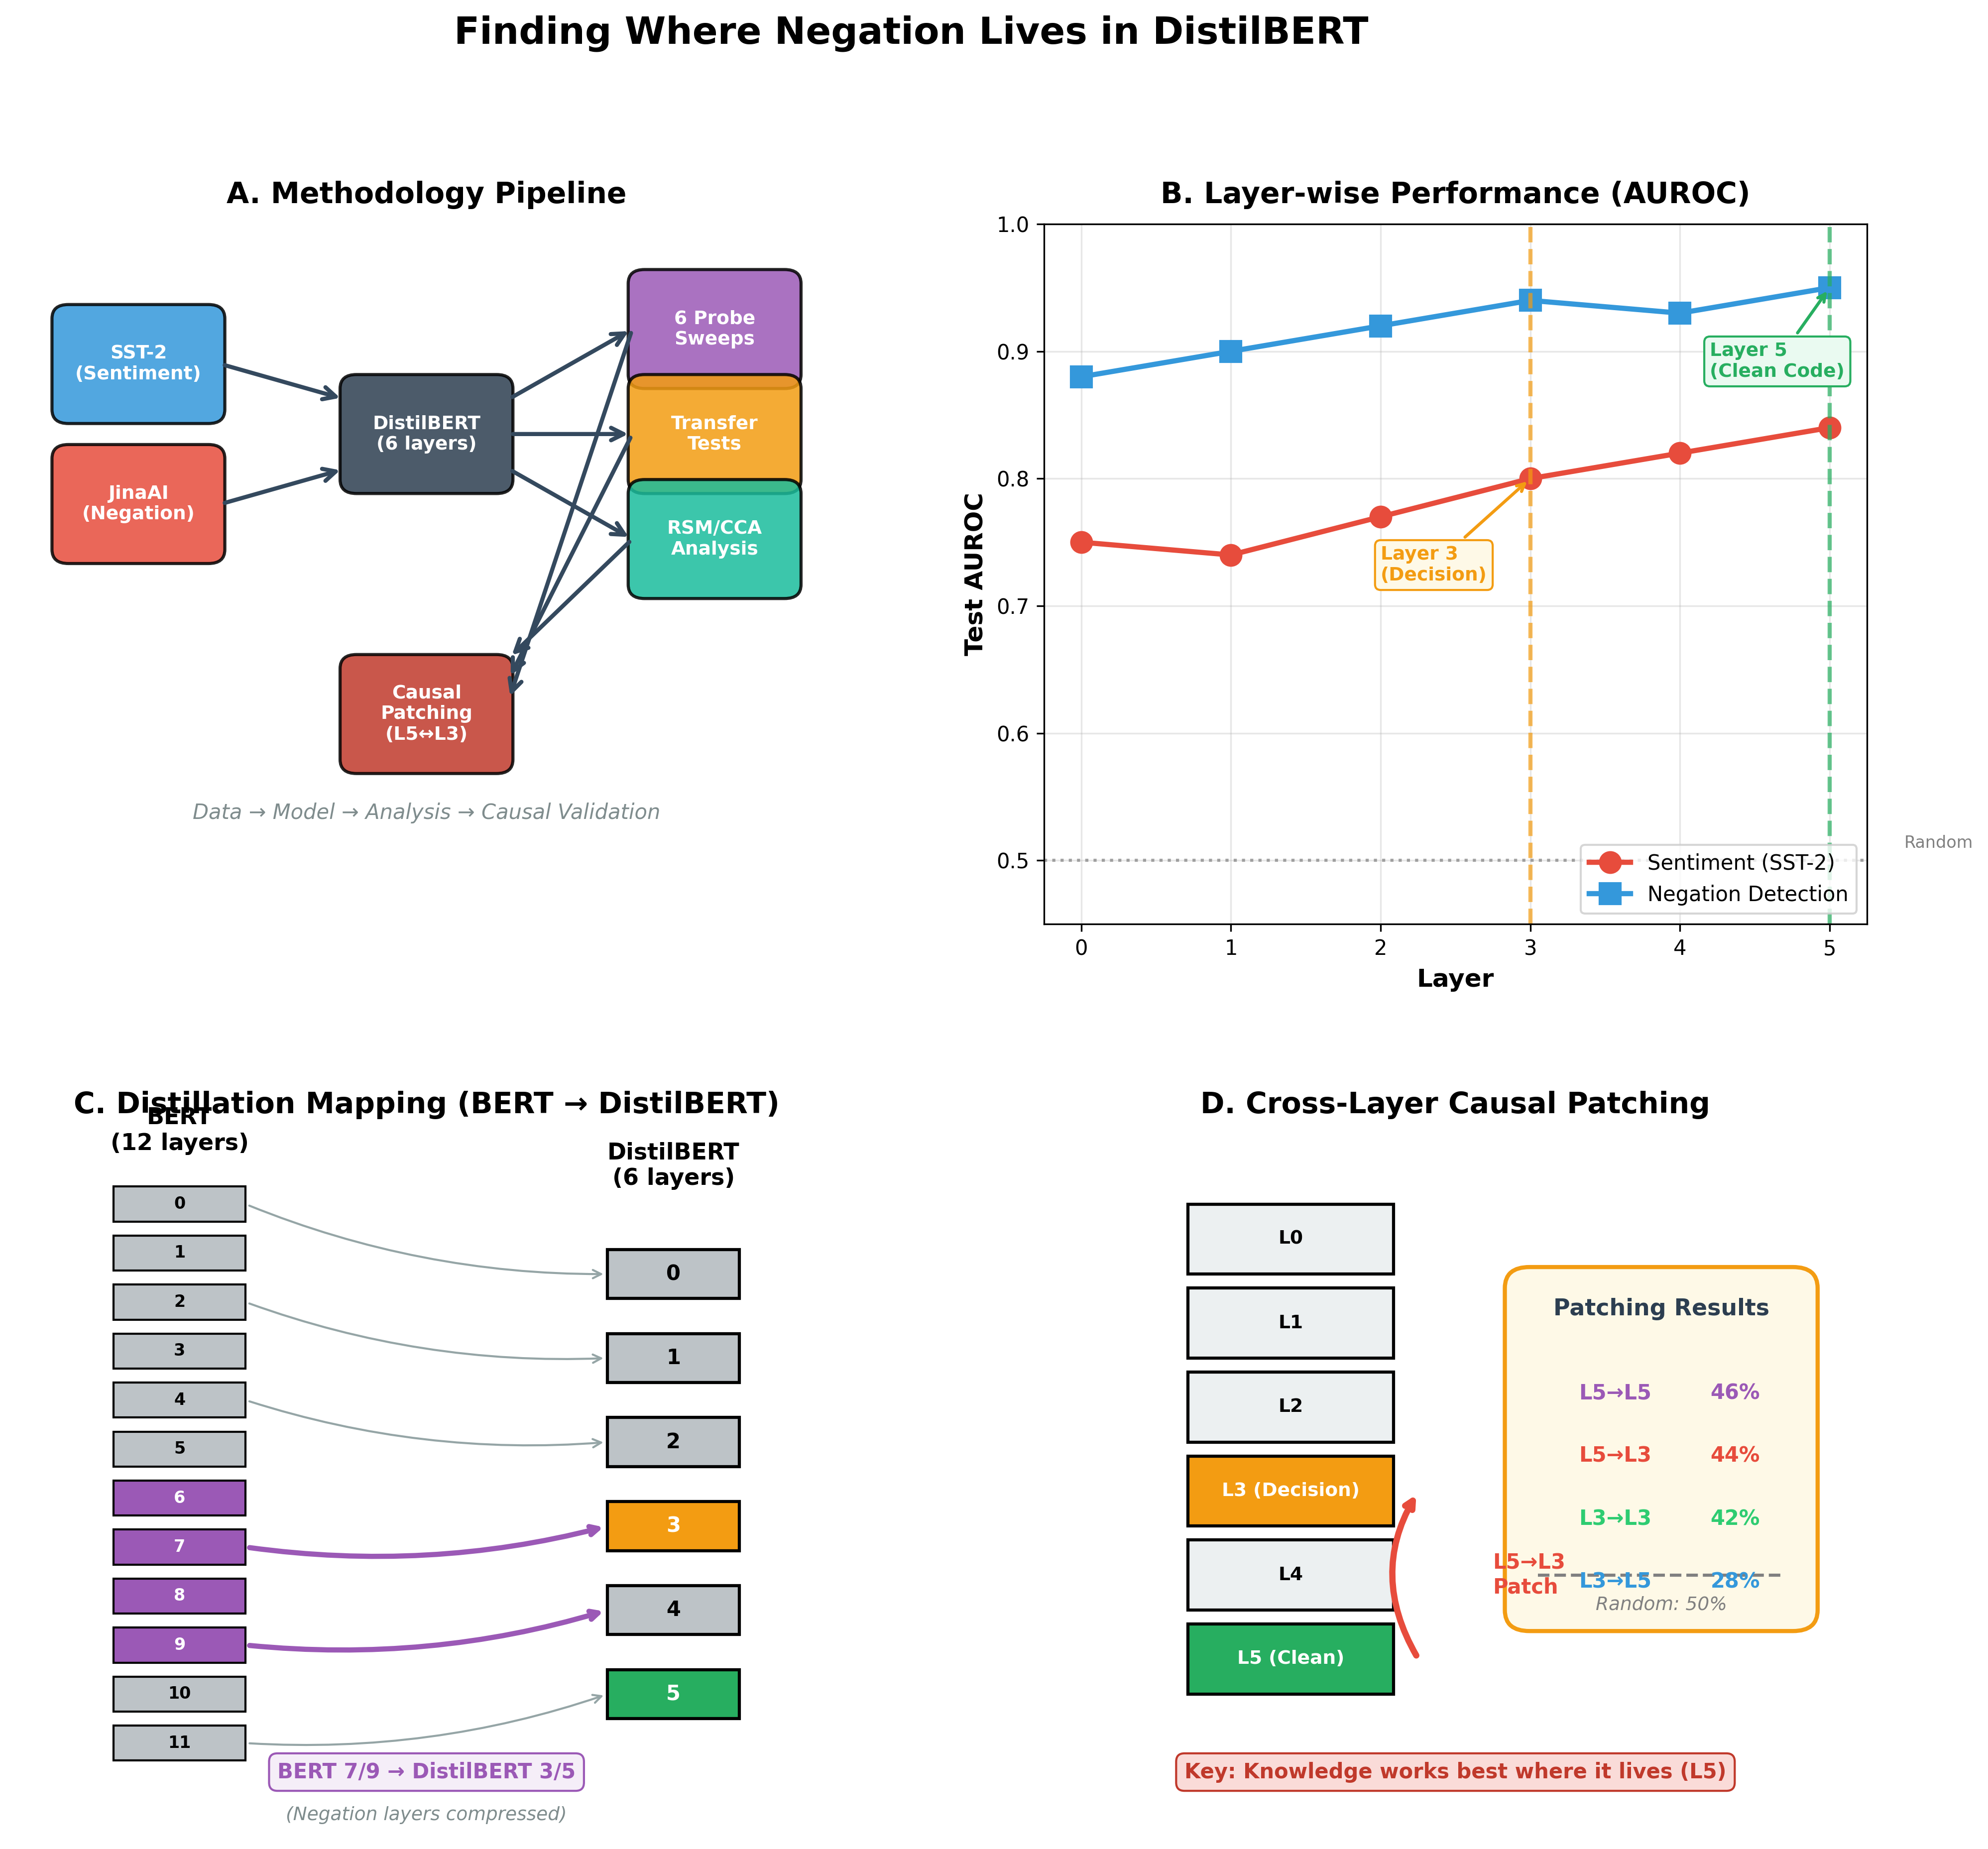

True

In [ ]:
# Visualization 4: The 2×2 Summary Panel
viz_path_summary = os.path.join(VISUALIZATIONS_DIR, 'summary_2x2_panel.png')

def create_summary_2x2_panel():
    """
    Create a 2×2 panel figure summarizing the entire methodology and findings:
    - Panel A: Method pipeline diagram
    - Panel B: Layer-wise AUROC curves
    - Panel C: Distillation map (BERT → DistilBERT)
    - Panel D: Causal patching cartoon
    """
    import matplotlib.patches as mpatches
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Circle

    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=(16, 14))

    # Use gridspec for better control
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

    # =========================================================================
    # PANEL A: Method Pipeline Diagram (top-left)
    # =========================================================================
    ax_a = fig.add_subplot(gs[0, 0])
    ax_a.set_xlim(0, 10)
    ax_a.set_ylim(0, 10)
    ax_a.axis('off')
    ax_a.set_title('A. Methodology Pipeline', fontsize=14, fontweight='bold', pad=10)

    # Pipeline boxes
    pipeline_boxes = [
        {'x': 1.5, 'y': 8, 'text': 'SST-2\n(Sentiment)', 'color': '#3498db'},
        {'x': 1.5, 'y': 6, 'text': 'JinaAI\n(Negation)', 'color': '#e74c3c'},
        {'x': 5, 'y': 7, 'text': 'DistilBERT\n(6 layers)', 'color': '#2c3e50'},
        {'x': 8.5, 'y': 8.5, 'text': '6 Probe\nSweeps', 'color': '#9b59b6'},
        {'x': 8.5, 'y': 7, 'text': 'Transfer\nTests', 'color': '#f39c12'},
        {'x': 8.5, 'y': 5.5, 'text': 'RSM/CCA\nAnalysis', 'color': '#1abc9c'},
        {'x': 5, 'y': 3, 'text': 'Causal\nPatching\n(L5↔L3)', 'color': '#c0392b'},
    ]

    for box in pipeline_boxes:
        rect = FancyBboxPatch((box['x']-1, box['y']-0.8), 2, 1.6,
                             boxstyle="round,pad=0.05,rounding_size=0.2",
                             facecolor=box['color'], edgecolor='black', linewidth=1.5, alpha=0.85)
        ax_a.add_patch(rect)
        ax_a.text(box['x'], box['y'], box['text'], ha='center', va='center',
                 fontsize=9, fontweight='bold', color='white')

    # Arrows
    arrow_style = dict(arrowstyle='->', color='#34495e', lw=2, mutation_scale=15)
    # Data → Model
    ax_a.annotate('', xy=(4, 7.5), xytext=(2.5, 8), arrowprops=arrow_style)
    ax_a.annotate('', xy=(4, 6.5), xytext=(2.5, 6), arrowprops=arrow_style)
    # Model → Analyses
    ax_a.annotate('', xy=(7.5, 8.5), xytext=(6, 7.5), arrowprops=arrow_style)
    ax_a.annotate('', xy=(7.5, 7), xytext=(6, 7), arrowprops=arrow_style)
    ax_a.annotate('', xy=(7.5, 5.5), xytext=(6, 6.5), arrowprops=arrow_style)
    # Analyses → Causal
    ax_a.annotate('', xy=(6, 3.8), xytext=(7.5, 5.5), arrowprops=arrow_style)
    ax_a.annotate('', xy=(6, 3.5), xytext=(7.5, 7), arrowprops=arrow_style)
    ax_a.annotate('', xy=(6, 3.2), xytext=(7.5, 8.5), arrowprops=arrow_style)

    # Labels
    ax_a.text(5, 1.5, 'Data → Model → Analysis → Causal Validation',
             ha='center', fontsize=10, style='italic', color='#7f8c8d')

    # =========================================================================
    # PANEL B: Layer-wise AUROC Curves (top-right)
    # =========================================================================
    ax_b = fig.add_subplot(gs[0, 1])
    ax_b.set_title('B. Layer-wise Performance (AUROC)', fontsize=14, fontweight='bold', pad=10)

    layers = [0, 1, 2, 3, 4, 5]
    # Example data (replace with actual if available)
    sentiment_auroc = [0.75, 0.74, 0.77, 0.80, 0.82, 0.84]
    negation_auroc = [0.88, 0.90, 0.92, 0.94, 0.93, 0.95]

    ax_b.plot(layers, sentiment_auroc, 'o-', color='#e74c3c', linewidth=2.5,
             markersize=10, label='Sentiment (SST-2)')
    ax_b.plot(layers, negation_auroc, 's-', color='#3498db', linewidth=2.5,
             markersize=10, label='Negation Detection')

    # Highlight layers 3 and 5
    ax_b.axvline(x=3, color='#f39c12', linestyle='--', linewidth=2, alpha=0.7)
    ax_b.axvline(x=5, color='#27ae60', linestyle='--', linewidth=2, alpha=0.7)

    # Annotations
    ax_b.annotate('Layer 3\n(Decision)', xy=(3, 0.80), xytext=(2, 0.72),
                 fontsize=9, fontweight='bold', color='#f39c12',
                 arrowprops=dict(arrowstyle='->', color='#f39c12', lw=1.5),
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef9e7', edgecolor='#f39c12'))
    ax_b.annotate('Layer 5\n(Clean Code)', xy=(5, 0.95), xytext=(4.2, 0.88),
                 fontsize=9, fontweight='bold', color='#27ae60',
                 arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5),
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', edgecolor='#27ae60'))

    # Random baseline
    ax_b.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax_b.text(5.5, 0.51, 'Random', fontsize=8, color='gray')

    ax_b.set_xlabel('Layer', fontsize=12, fontweight='bold')
    ax_b.set_ylabel('Test AUROC', fontsize=12, fontweight='bold')
    ax_b.set_xticks(layers)
    ax_b.set_ylim(0.45, 1.0)
    ax_b.legend(loc='lower right', fontsize=10)
    ax_b.grid(True, alpha=0.3)

    # =========================================================================
    # PANEL C: Distillation Map (bottom-left)
    # =========================================================================
    ax_c = fig.add_subplot(gs[1, 0])
    ax_c.set_xlim(0, 10)
    ax_c.set_ylim(0, 10)
    ax_c.axis('off')
    ax_c.set_title('C. Distillation Mapping (BERT → DistilBERT)', fontsize=14, fontweight='bold', pad=10)

    # BERT layers (left column)
    bert_x = 2
    bert_layers = list(range(12))
    bert_y_positions = [9 - i * 0.7 for i in range(12)]

    for i, y in enumerate(bert_y_positions):
        color = '#9b59b6' if i in [6, 7, 8, 9] else '#bdc3c7'
        rect = Rectangle((bert_x - 0.8, y - 0.25), 1.6, 0.5,
                         facecolor=color, edgecolor='black', linewidth=1)
        ax_c.add_patch(rect)
        ax_c.text(bert_x, y, f'{i}', ha='center', va='center', fontsize=8,
                 fontweight='bold', color='white' if i in [6,7,8,9] else 'black')

    ax_c.text(bert_x, 9.7, 'BERT\n(12 layers)', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

    # DistilBERT layers (right column)
    distil_x = 8
    distil_layers = list(range(6))
    distil_y_positions = [8 - i * 1.2 for i in range(6)]

    for i, y in enumerate(distil_y_positions):
        color = '#f39c12' if i == 3 else ('#27ae60' if i == 5 else '#bdc3c7')
        rect = Rectangle((distil_x - 0.8, y - 0.35), 1.6, 0.7,
                         facecolor=color, edgecolor='black', linewidth=1.5)
        ax_c.add_patch(rect)
        ax_c.text(distil_x, y, f'{i}', ha='center', va='center', fontsize=10,
                 fontweight='bold', color='white' if i in [3, 5] else 'black')

    ax_c.text(distil_x, 9.2, 'DistilBERT\n(6 layers)', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

    # Mapping arrows (key ones)
    mapping = [(0, 0), (2, 1), (4, 2), (7, 3), (9, 4), (11, 5)]
    for bert_idx, distil_idx in mapping:
        bert_y = bert_y_positions[bert_idx]
        distil_y = distil_y_positions[distil_idx]
        color = '#9b59b6' if bert_idx in [7, 9] else '#95a5a6'
        lw = 2.5 if bert_idx in [7, 9] else 1
        ax_c.annotate('', xy=(distil_x - 0.8, distil_y), xytext=(bert_x + 0.8, bert_y),
                     arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                    connectionstyle='arc3,rad=0.1'))

    # Legend
    ax_c.text(5, 0.8, 'BERT 7/9 → DistilBERT 3/5', ha='center', fontsize=10,
             fontweight='bold', color='#9b59b6',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5eef8', edgecolor='#9b59b6'))
    ax_c.text(5, 0.2, '(Negation layers compressed)', ha='center', fontsize=9,
             style='italic', color='#7f8c8d')

    # =========================================================================
    # PANEL D: Causal Patching Cartoon (bottom-right)
    # =========================================================================
    ax_d = fig.add_subplot(gs[1, 1])
    ax_d.set_xlim(0, 10)
    ax_d.set_ylim(0, 10)
    ax_d.axis('off')
    ax_d.set_title('D. Cross-Layer Causal Patching', fontsize=14, fontweight='bold', pad=10)

    # DistilBERT stack
    stack_x = 3
    layer_height = 1.2
    layer_width = 2.5

    for i in range(6):
        y = 8.5 - i * layer_height
        color = '#f39c12' if i == 3 else ('#27ae60' if i == 5 else '#ecf0f1')
        rect = Rectangle((stack_x - layer_width/2, y - 0.5), layer_width, 1,
                         facecolor=color, edgecolor='black', linewidth=1.5)
        ax_d.add_patch(rect)
        label = f'L{i}'
        if i == 3:
            label = 'L3 (Decision)'
        elif i == 5:
            label = 'L5 (Clean)'
        ax_d.text(stack_x, y, label, ha='center', va='center', fontsize=9, fontweight='bold',
                 color='white' if i in [3, 5] else 'black')

    # Patching arrows
    # L5 → L3 arrow (main hypothesis)
    l5_y = 8.5 - 5 * layer_height
    l3_y = 8.5 - 3 * layer_height
    ax_d.annotate('', xy=(stack_x + layer_width/2 + 0.3, l3_y),
                 xytext=(stack_x + layer_width/2 + 0.3, l5_y),
                 arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=3,
                                connectionstyle='arc3,rad=-0.3'))
    ax_d.text(stack_x + layer_width/2 + 1.2, (l5_y + l3_y)/2, 'L5→L3\nPatch',
             ha='left', va='center', fontsize=10, fontweight='bold', color='#e74c3c')

    # Results box
    results_x = 7.5
    results_y = 5.5

    results_box = FancyBboxPatch((results_x - 1.8, results_y - 2.5), 3.6, 5,
                                boxstyle="round,pad=0.1,rounding_size=0.3",
                                facecolor='#fef9e7', edgecolor='#f39c12', linewidth=2)
    ax_d.add_patch(results_box)

    ax_d.text(results_x, results_y + 2, 'Patching Results', ha='center', va='center',
             fontsize=11, fontweight='bold', color='#2c3e50')

    # Results data
    results_data = [
        ('L5→L5', '46%', '#9b59b6'),
        ('L5→L3', '44%', '#e74c3c'),
        ('L3→L3', '42%', '#2ecc71'),
        ('L3→L5', '28%', '#3498db'),
    ]

    for i, (cond, acc, color) in enumerate(results_data):
        y_offset = results_y + 0.8 - i * 0.9
        ax_d.text(results_x - 1, y_offset, cond, ha='left', va='center',
                 fontsize=10, fontweight='bold', color=color)
        ax_d.text(results_x + 1.2, y_offset, acc, ha='right', va='center',
                 fontsize=10, fontweight='bold', color=color)

    # Random baseline
    ax_d.plot([results_x - 1.5, results_x + 1.5], [results_y - 1.8, results_y - 1.8],
             '--', color='gray', linewidth=1.5)
    ax_d.text(results_x, results_y - 2.1, 'Random: 50%', ha='center', va='top',
             fontsize=9, color='gray', style='italic')

    # Key insight
    ax_d.text(5, 0.8, 'Key: Knowledge works best where it lives (L5)',
             ha='center', fontsize=10, fontweight='bold', color='#c0392b',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#fadbd8', edgecolor='#c0392b'))

    # =========================================================================
    # Overall title
    # =========================================================================
    fig.suptitle('Finding Where Negation Lives in DistilBERT',
                fontsize=18, fontweight='bold', y=0.98)

    plt.savefig(viz_path_summary, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✓ 2×2 Summary panel saved to {viz_path_summary}")

# Check or create visualization
check_or_create_visualization(viz_path_summary, create_summary_2x2_panel)

# Display visualization
display_visualization(viz_path_summary, title="2×2 Summary Panel: The Big Picture")


## 4. Summary

All visualizations have been checked and displayed above. If any visualizations were created, they have been saved to:
`{VISUALIZATIONS_DIR}`


In [25]:
# List all visualizations in the directory
print("All visualizations in final_visualizations directory:")
print("=" * 60)

if os.path.exists(VISUALIZATIONS_DIR):
    viz_files = sorted([f for f in os.listdir(VISUALIZATIONS_DIR) if f.endswith(('.png', '.jpg', '.pdf', '.svg'))])
    if viz_files:
        for i, viz_file in enumerate(viz_files, 1):
            viz_path = os.path.join(VISUALIZATIONS_DIR, viz_file)
            size_mb = os.path.getsize(viz_path) / (1024 * 1024)
            print(f"{i}. {viz_file} ({size_mb:.2f} MB)")
    else:
        print("No visualization files found.")
else:
    print(f"Directory does not exist: {VISUALIZATIONS_DIR}")


All visualizations in final_visualizations directory:
1. causal_patching_conditions.png (0.23 MB)
2. causal_punchline.png (0.21 MB)
3. knowledge_progression_puzzle.png (0.07 MB)
4. layer_performance_table.png (0.07 MB)
5. summary_2x2_panel.png (0.58 MB)
